In [ ]:
!pip install pywaffle==0.6.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.9/565.9 kB 19.7 MB/s eta 0:00:00


**Step 1: Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

from yellowbrick.cluster import KElbowVisualizer
from pywaffle import Waffle

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

**Step 2: Load the Dataset**

In [ ]:
df = pd.read_csv('financial_analysis.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
print(df.head())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  
0         0         0   

**Step 3: Feature Engineering**

In [ ]:
df['TOTAL_PAY'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                      'PAY_AMT4','PAY_AMT5','PAY_AMT6']].sum(axis=1)

df['TOTAL_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                       'BILL_AMT4','BILL_AMT5','BILL_AMT6']].sum(axis=1)

df.drop(columns=[
    'ID',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6'
], inplace=True)

**Step 4: Categorical Attribute Analysis**

In [ ]:
print("SEX Distribution:\n", df['SEX'].value_counts())
print("EDUCATION Distribution:\n", df['EDUCATION'].value_counts())

SEX Distribution:
 SEX
2    18112
1    11888
Name: count, dtype: int64
EDUCATION Distribution:
 EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


** Step 5: Data Cleaning**

In [ ]:
df = df[~df['EDUCATION'].isin([5, 6])]
df.reset_index(drop=True, inplace=True)

**Step 6: Correlation HeatMap**

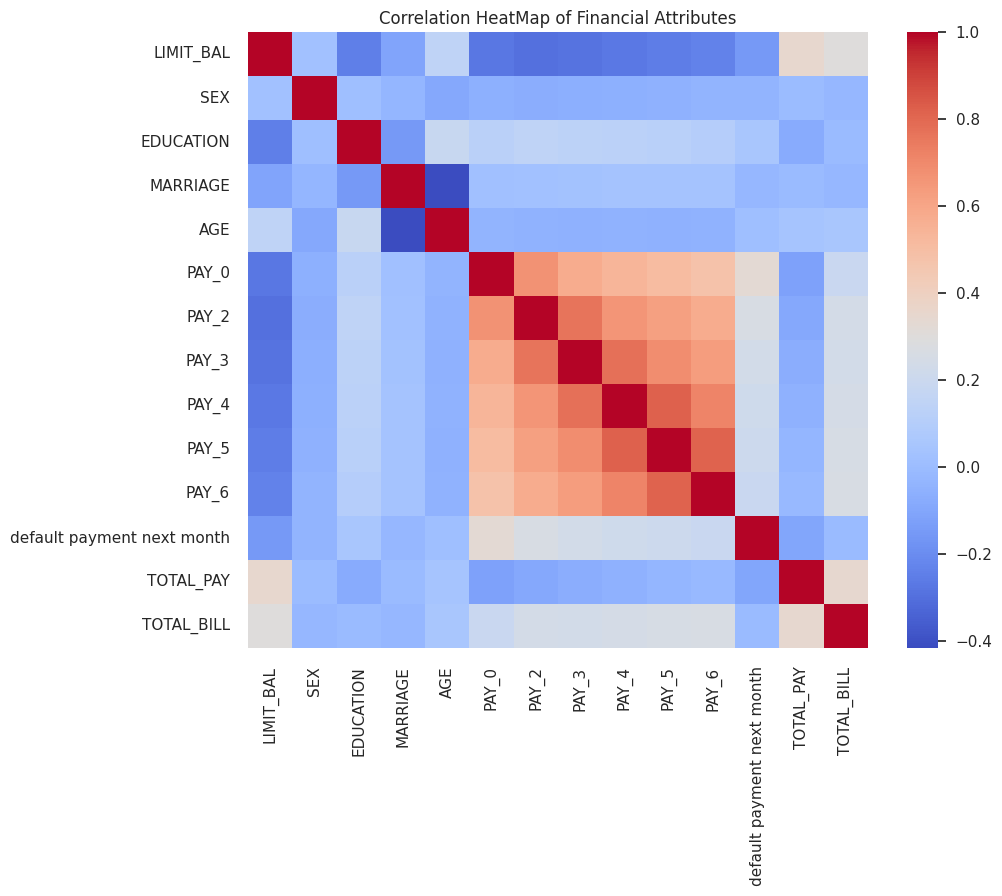

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation HeatMap of Financial Attributes")
plt.show()

**Step 7: Data Scaling**

In [ ]:
num_df = df.select_dtypes(include=np.number)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(num_df)

**Step 8: Principal Component Analysis (PCA)**

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

X = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
print("PCA Data Shape:", X.shape)

PCA Data Shape: (29669, 2)


**Step 9: Histogram Analysis**

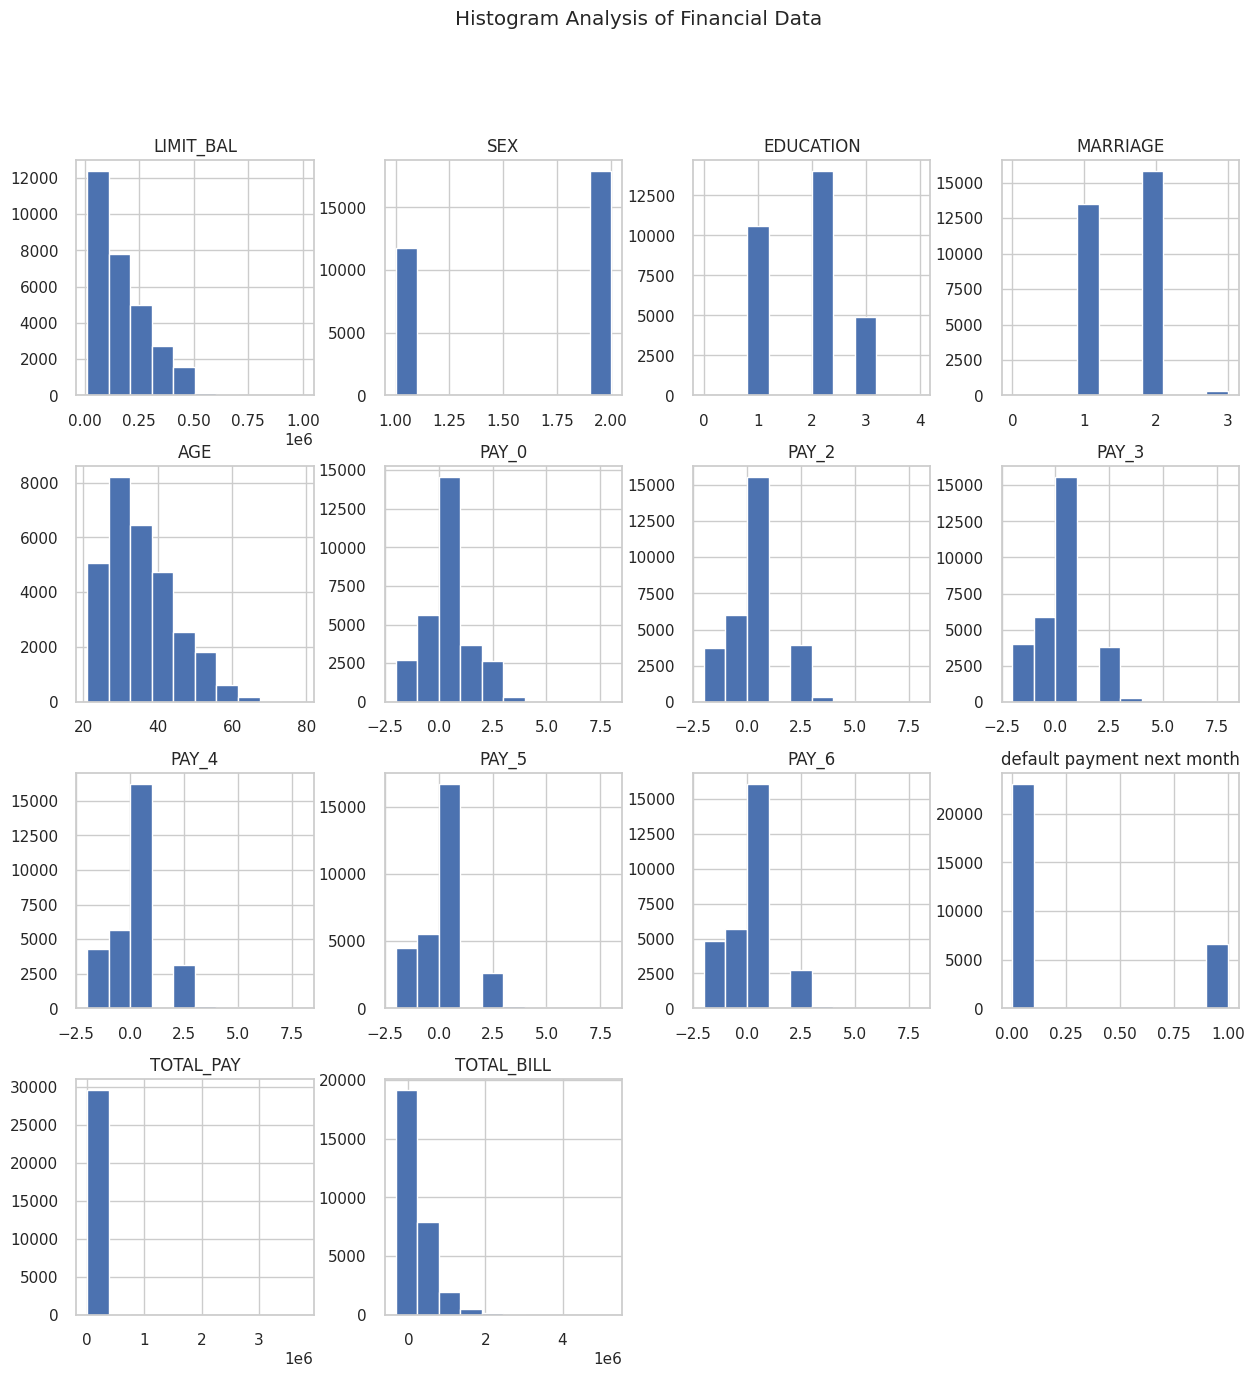

In [ ]:
df.hist(figsize=(15,15))
plt.suptitle("Histogram Analysis of Financial Data")
plt.show()

**Step 10: Optimal Cluster Selection (Elbow Method)**

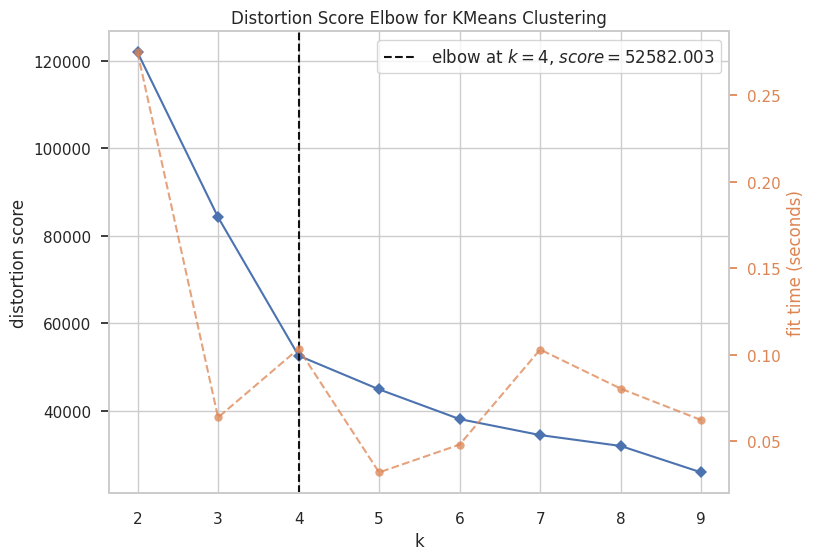

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
plt.figure(figsize=(8,6))
elbow = KElbowVisualizer(KMeans(random_state=42), k=(2,10))
elbow.fit(X)
elbow.show()

**Step 11: K-Means Clustering**

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, max_iter=500)
y_kmeans = kmeans.fit_predict(X)

**Step 12: PCA Clustered DataFrame**

In [ ]:
pca_df = X.copy()
pca_df['Cluster'] = y_kmeans
print(pca_df.head())

        PC1       PC2  Cluster
0  0.026256 -2.026707        0
1  1.724831 -1.219378        0
2  0.365004 -0.860664        0
3  0.413760 -0.434263        0
4 -0.302577  0.406030        0


**Step 13: Cluster Distribution – Waffle Chart**

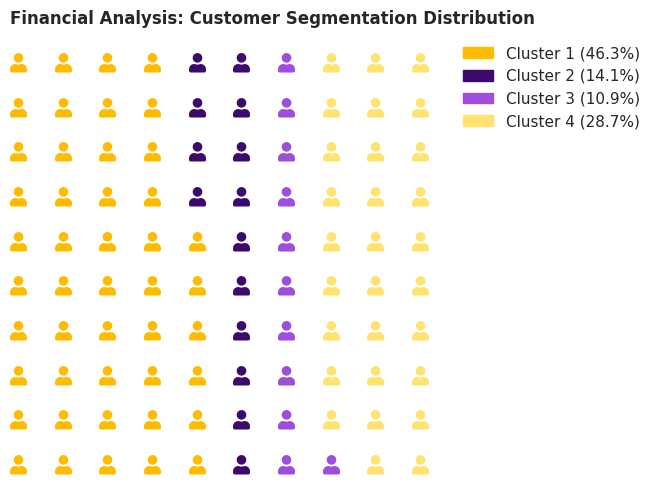

In [ ]:
unique, counts = np.unique(y_kmeans, return_counts=True)
total_customers = sum(counts)

percentages = (counts / total_customers) * 100

data_for_waffle = {
    f"Cluster {i+1}": round(p, 1)
    for i, p in zip(unique, percentages)
}

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    columns=10,
    values=data_for_waffle,
    colors=['#FFBB00', '#3C096C', '#9D4EDD', '#FFE270'],
    icons='user',
    icon_size=14,
    legend={
        'labels': [
            f"Cluster {i+1} ({round(p,1)}%)"
            for i, p in zip(unique, percentages)
        ],
        'loc': 'upper left',
        'bbox_to_anchor': (1, 1),
        'frameon': False
    },
    figsize=(10, 5)
)

plt.title(
    "Financial Analysis: Customer Segmentation Distribution",
    loc='left',
    weight='bold'
)
plt.show()

**Step 14: Cluster Evaluation Metrics**

In [ ]:
print("Silhouette Score:", silhouette_score(X, y_kmeans))
print("Davies Bouldin Score:", davies_bouldin_score(X, y_kmeans))

Silhouette Score: 0.4609407793401767
Davies Bouldin Score: 0.7236005331533095


**Step 15: Cluster-wise Data Segregation**

In [ ]:
cluster_df = df.copy()
cluster_df['Cluster'] = y_kmeans

print("\nCluster-wise Mean Values:")
print(cluster_df.groupby('Cluster').mean())


Cluster-wise Mean Values:
             LIMIT_BAL       SEX  EDUCATION  MARRIAGE        AGE     PAY_0  \
Cluster                                                                      
0        106677.773736  1.596726   1.942597  1.625173  34.079302  0.130593   
1        325567.244849  1.554863   1.653091  1.423814  38.426449 -0.055822   
2         86128.932758  1.544417   1.984886  1.543800  35.001542  1.632326   
3        219258.345087  1.660320   1.628115  1.502233  36.444640 -0.859426   

            PAY_2     PAY_3     PAY_4     PAY_5     PAY_6  \
Cluster                                                     
0        0.103238  0.081048  0.011495 -0.054129 -0.077119   
1       -0.086248 -0.078821 -0.074269 -0.068519 -0.062770   
2        1.894201  1.915176  1.790253  1.608267  1.441394   
3       -1.306065 -1.393512 -1.427598 -1.414551 -1.399271   

         default payment next month      TOTAL_PAY     TOTAL_BILL  
Cluster                                                            
0

**Step 16: Cluster Count Visualization**

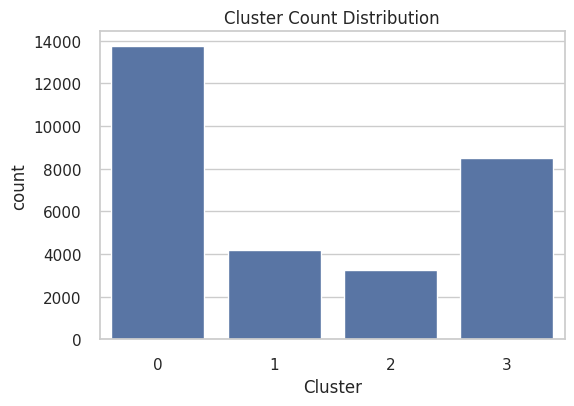

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Cluster', data=cluster_df)
plt.title("Cluster Count Distribution")
plt.show()

**Step 17: Feature-wise Cluster Analysis**

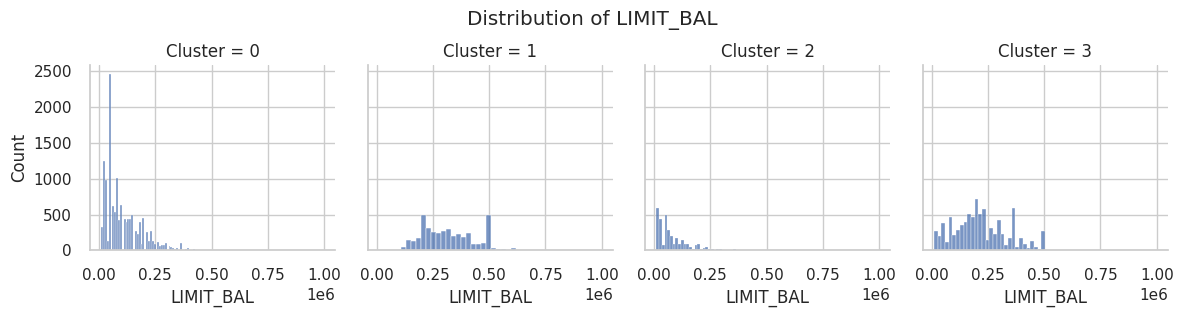

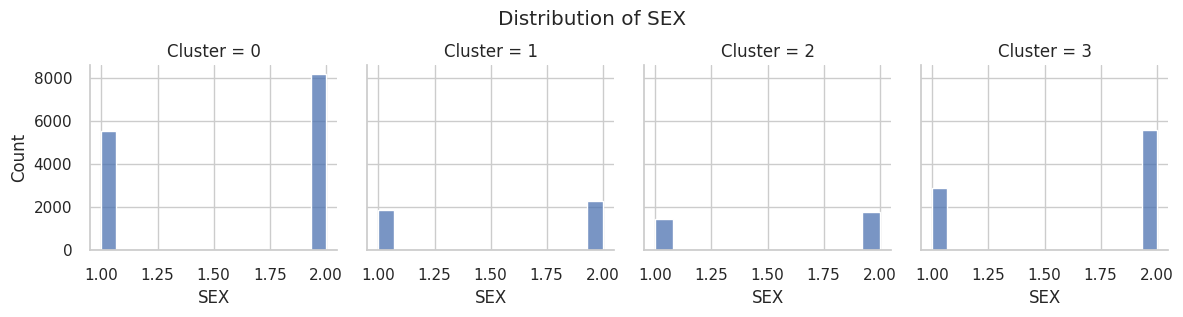

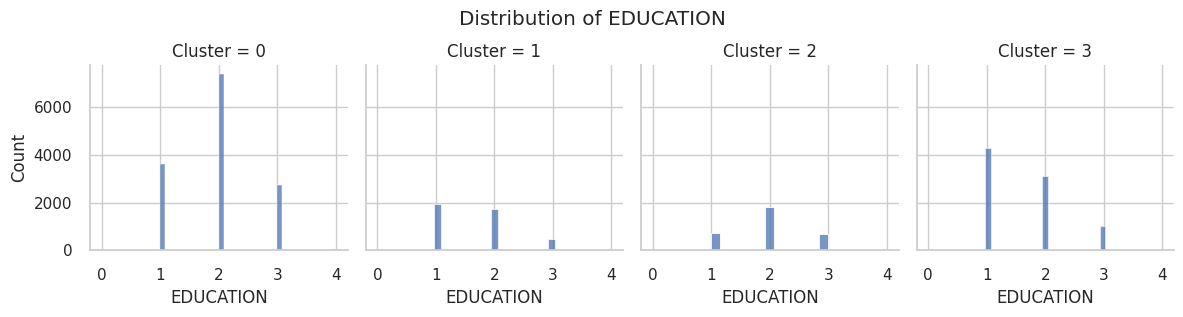

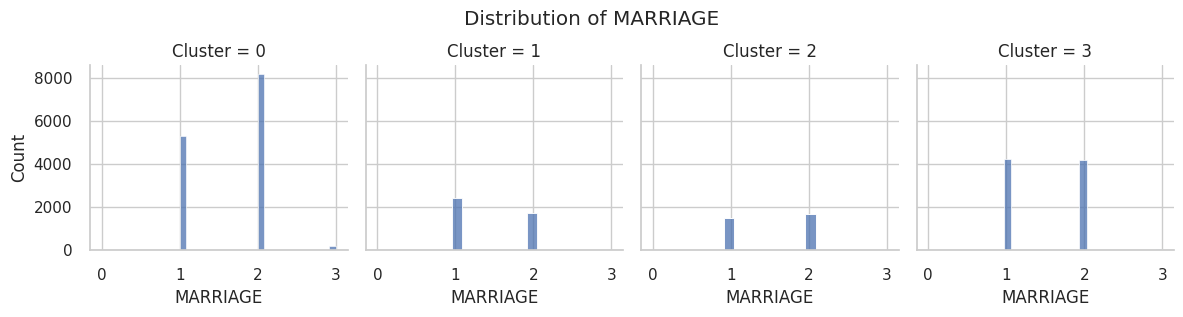

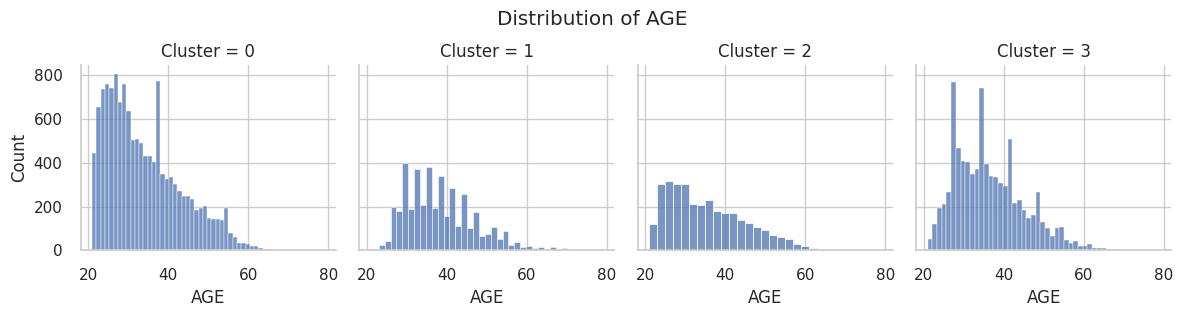

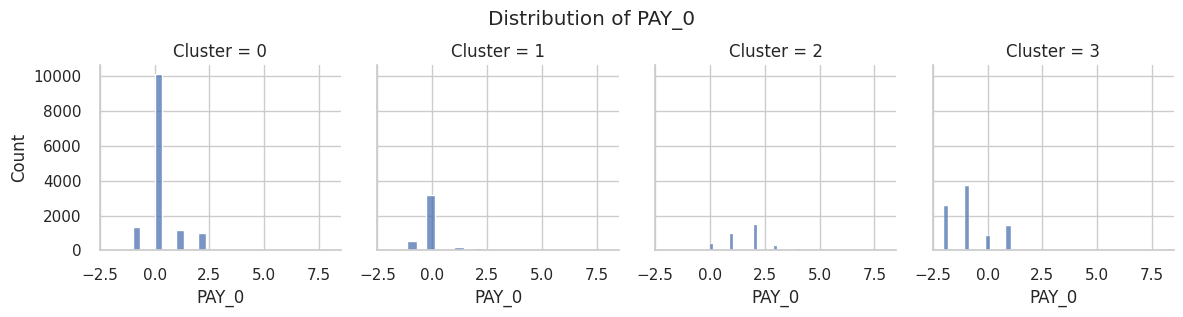

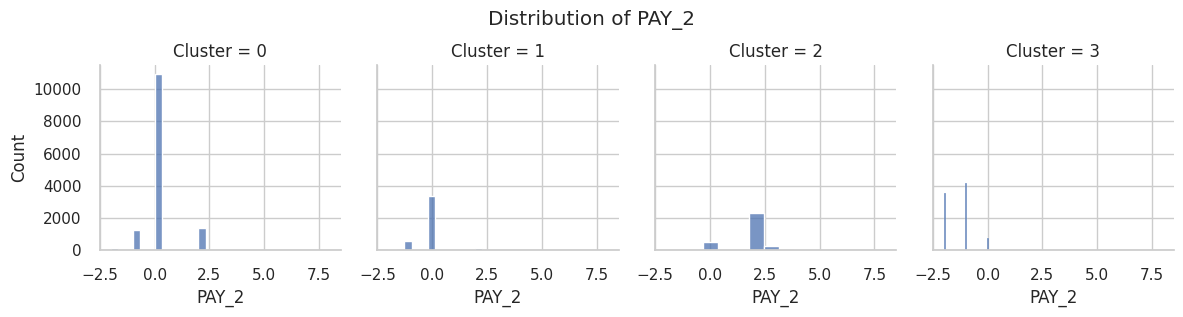

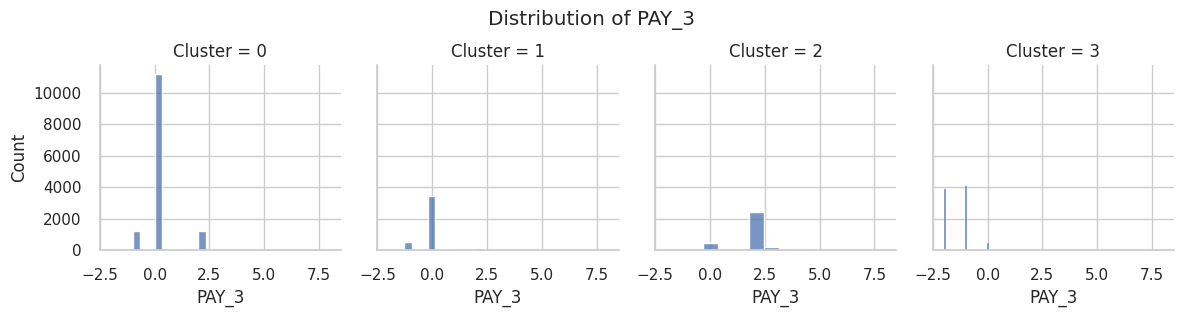

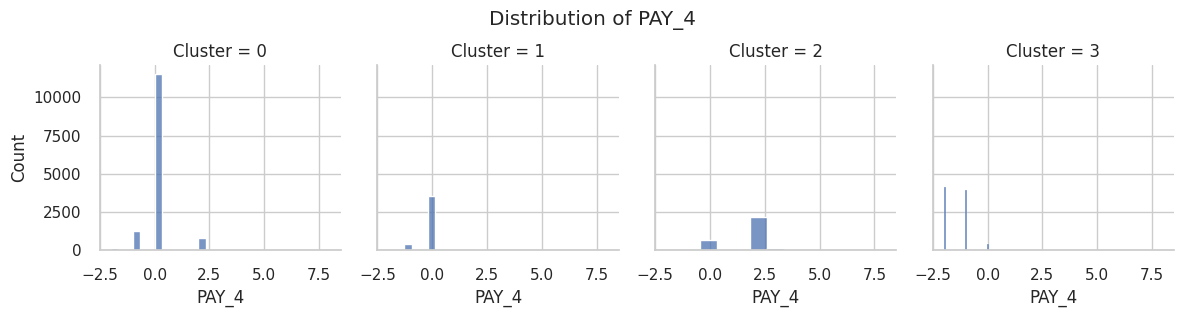

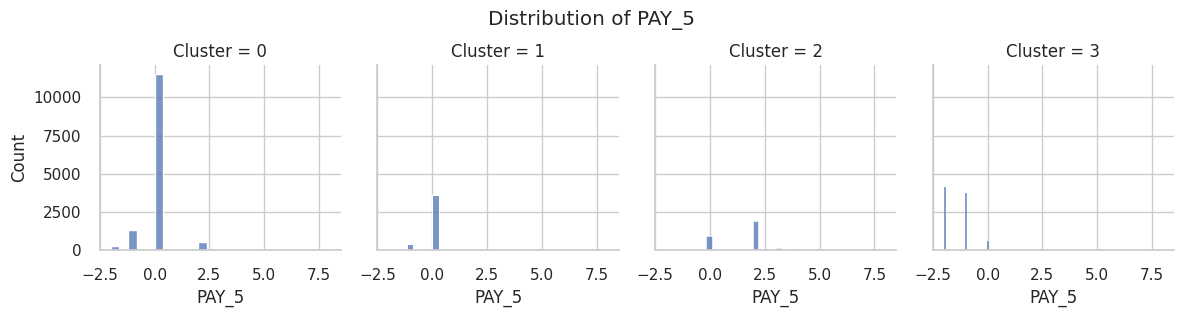

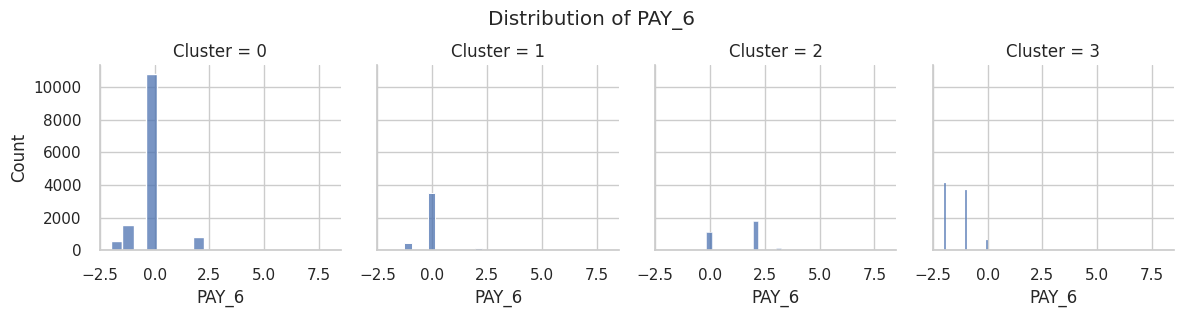

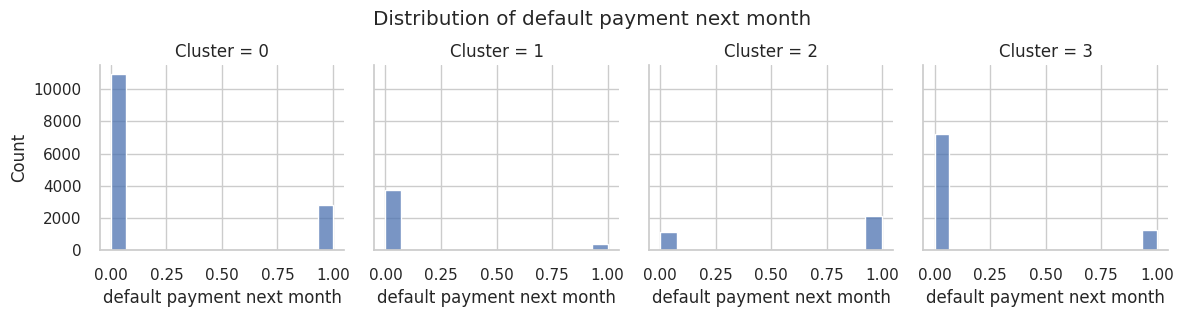

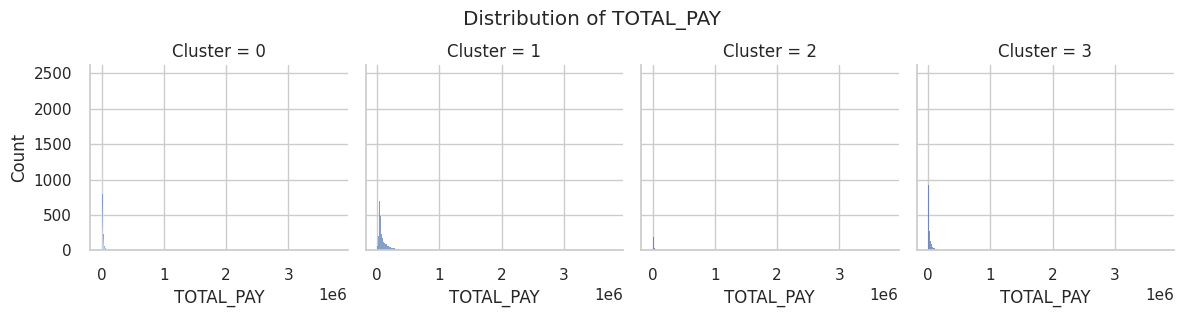

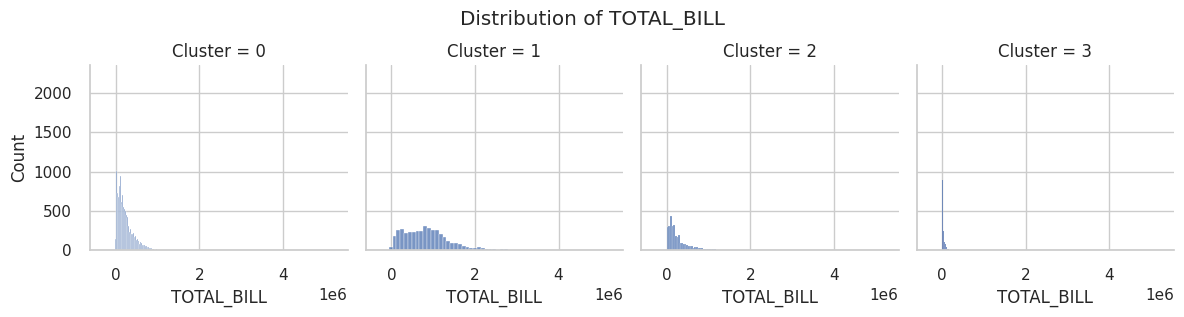

In [ ]:
for col in cluster_df.drop('Cluster', axis=1).columns:
    g = sns.FacetGrid(cluster_df, col='Cluster')
    g.map_dataframe(sns.histplot, col)
    g.fig.suptitle(f"Distribution of {col}", y=1.05)
    plt.show()

**Understanding Clusters**


*  **Cluster 0:** Customers with moderate credit limits, low to moderate spending, and mostly regular payment behavior.


*   **Cluster 1:** High credit limit customers with high spending and timely payments, representing low default risk.


*   **Cluster 2:** Low credit limit customers with delayed payments and the highest default risk among all clusters.


*   **Cluster 3:** Customers with fairly high credit limits, controlled spending, and consistent on-time or early payments.




